# 05 — Response Surface Methods (RSM)
**References:** Box & Wilson (1951) · Box & Draper (1987) · Montgomery (2017) Ch. 11

## Narrative thread
```
Screening -> Near optimum -> Response surface -> Central Composite Design -> Canonical analysis -> Optimization
```

## From factorial to RSM

**Phase 1 (screening):** Fractional factorial to identify the 2–4 active factors.

**Phase 2 (RSM):** Fit a **second-order (quadratic) model** near the optimum:
$$y = \beta_0 + \sum_{i=1}^k \beta_i x_i + \sum_{i=1}^k \beta_{ii} x_i^2 + \sum_{i<j} \beta_{ij} x_i x_j + \varepsilon$$

A 2-level factorial cannot estimate $\beta_{ii}$ (pure quadratic terms) — we need at least 3 levels.

## Central Composite Design (CCD)

A 2^k factorial + $2k$ **axial (star) points** at $\pm \alpha$ + $n_0$ center points.

Total runs: $2^k + 2k + n_0$

For $k=2$: $4 + 4 + n_0$ runs. Compare to $3^2 = 9$ (full 3-level factorial).

**Choice of $\alpha$:**
- $\alpha = 1$: **face-centered CCD** (FCF) — axial points on face of cube, only 3 levels
- $\alpha = \sqrt{k}$: **spherical** design — all points equidistant from center  
- $\alpha = 2^{k/4}$: **rotatable** — prediction variance constant at equal distance from center

## Box-Behnken Design (BBD)

Alternative to CCD: no axial points outside the cube. Better when extreme combinations of factors are impossible or dangerous. Requires $k \geq 3$.

## Canonical analysis

Rewrite the fitted surface in canonical (principal axis) form:
$$\hat{y} = \hat{y}_s + \mathbf{w}^\top \boldsymbol{\Lambda} \mathbf{w}$$

where $\boldsymbol{\Lambda}$ = diagonal matrix of eigenvalues of $\hat{B}$ (matrix of quadratic/cross terms).

| Eigenvalues | Surface type | Action |
|---|---|---|
| All negative | Maximum | Optimum found |
| All positive | Minimum | Optimum found |
| Mixed signs | Saddle point | No unique optimum — ridge analysis |
| One near zero | Ridge system | Optimum along a line |

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from itertools import product

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
})
np.random.seed(42)

CCD for k=2: 12 runs (4 factorial + 4 axial + 4 center)

Fitted model: y = 0.2348 + 0.0399x1 + -0.0159x2
               + -0.0384x1^2 + -0.0261x2^2 + 0.0086x1*x2
R^2 = 0.9935

Stationary point: x1*=0.4948  x2*=-0.2235  y*=0.2465
Eigenvalues of B: [-0.03972095 -0.02477266]
Surface type: Maximum


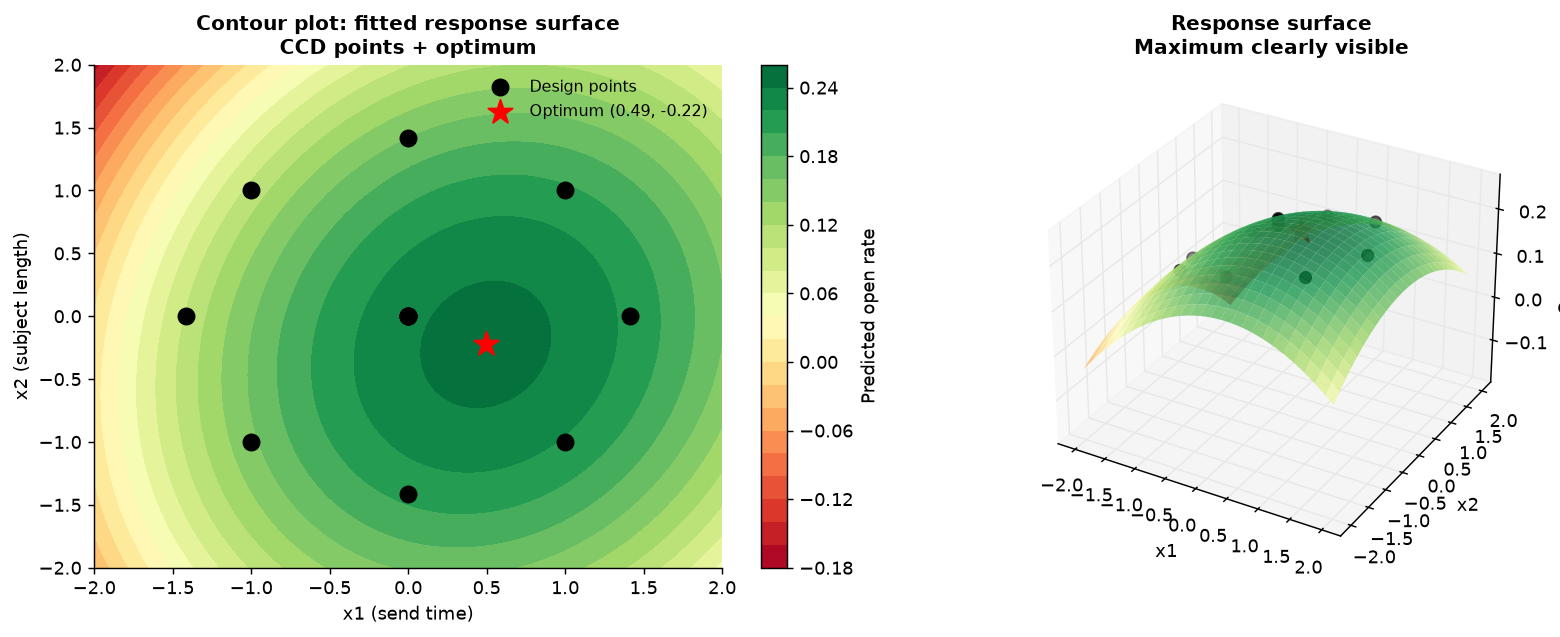


Optimal send time: 11.0:00
Optimal subject length: 46 characters


In [2]:
# ── Central Composite Design (CCD) for 2 factors ─────────────────────────
# Context: optimize email campaign
# x1 = send time (centered: 0 = 10am, ±1 = ±2h)
# x2 = subject length (centered: 0 = 50 chars, ±1 = ±20 chars)
# Response: open rate

alpha_ccd = np.sqrt(2)  # rotatable for k=2
n0 = 4   # center points

# CCD design points
factorial_pts = np.array(list(product([-1,1], repeat=2)), dtype=float)
axial_pts = np.array([[-alpha_ccd,0],[alpha_ccd,0],[0,-alpha_ccd],[0,alpha_ccd]], dtype=float)
center_pts = np.zeros((n0, 2))
design_ccd = np.vstack([factorial_pts, axial_pts, center_pts])

print(f'CCD for k=2: {len(design_ccd)} runs (4 factorial + 4 axial + {n0} center)')

# True response: quadratic surface with maximum
def true_response(x1, x2):
    return (0.25 - 0.04*(x1 - 0.5)**2 - 0.03*(x2 + 0.3)**2
            + 0.01*x1*x2 + np.random.normal(0, 0.005))

np.random.seed(99)
y_ccd = np.array([true_response(x1, x2) for x1, x2 in design_ccd])

# Fit second-order model
X_ccd = np.column_stack([
    np.ones(len(design_ccd)),
    design_ccd[:,0],        # x1
    design_ccd[:,1],        # x2
    design_ccd[:,0]**2,     # x1^2
    design_ccd[:,1]**2,     # x2^2
    design_ccd[:,0]*design_ccd[:,1],  # x1*x2
])
mod_rsm = sm.OLS(y_ccd, X_ccd).fit()

b0, b1, b2, b11, b22, b12 = mod_rsm.params
print(f'\nFitted model: y = {b0:.4f} + {b1:.4f}x1 + {b2:.4f}x2')
print(f'               + {b11:.4f}x1^2 + {b22:.4f}x2^2 + {b12:.4f}x1*x2')
print(f'R^2 = {mod_rsm.rsquared:.4f}')

# Find stationary point: d(y_hat)/dx = 0 -> B*x_s = -b/2
b_vec = np.array([b1, b2])
B_mat = np.array([[b11, b12/2], [b12/2, b22]])
x_s   = -0.5 * np.linalg.inv(B_mat) @ b_vec
y_s   = b0 + b_vec @ x_s + x_s @ B_mat @ x_s
print(f'\nStationary point: x1*={x_s[0]:.4f}  x2*={x_s[1]:.4f}  y*={y_s:.4f}')

# Eigenanalysis
eigenvalues, eigenvectors = np.linalg.eigh(B_mat)
print(f'Eigenvalues of B: {eigenvalues}')
print('Surface type:', 'Maximum' if all(eigenvalues < 0) else 'Minimum' if all(eigenvalues > 0) else 'Saddle')

# Contour + response surface plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x1g = np.linspace(-2, 2, 100); x2g = np.linspace(-2, 2, 100)
X1, X2 = np.meshgrid(x1g, x2g)
Y_pred = b0 + b1*X1 + b2*X2 + b11*X1**2 + b22*X2**2 + b12*X1*X2

cont = axes[0].contourf(X1, X2, Y_pred, levels=25, cmap='RdYlGn')
plt.colorbar(cont, ax=axes[0], label='Predicted open rate')
axes[0].scatter(design_ccd[:,0], design_ccd[:,1], s=80,
                color='black', zorder=5, label='Design points')
axes[0].scatter(x_s[0], x_s[1], s=200, color='red', marker='*',
                zorder=6, label=f'Optimum ({x_s[0]:.2f}, {x_s[1]:.2f})')
axes[0].set_xlabel('x1 (send time)'); axes[0].set_ylabel('x2 (subject length)')
axes[0].set_title('Contour plot: fitted response surface\nCCD points + optimum')
axes[0].legend(fontsize=9)

# 3D surface
ax3d = fig.add_subplot(122, projection='3d')
ax3d.plot_surface(X1, X2, Y_pred, cmap='RdYlGn', alpha=0.8, rstride=4, cstride=4)
ax3d.scatter(design_ccd[:,0], design_ccd[:,1], y_ccd, color='black', s=40, zorder=5)
ax3d.scatter([x_s[0]], [x_s[1]], [y_s], color='red', s=200, marker='*', zorder=6)
ax3d.set_xlabel('x1'); ax3d.set_ylabel('x2'); ax3d.set_zlabel('Open rate')
ax3d.set_title('Response surface\nMaximum clearly visible')
axes[1].set_visible(False)

plt.tight_layout()
plt.show()
print(f'\nOptimal send time: {10 + x_s[0]*2:.1f}:00')
print(f'Optimal subject length: {50 + x_s[1]*20:.0f} characters')